In [1]:
from google.colab import drive
import os
import shutil

# Remove the directory if it's corrupted or not empty to allow mounting
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [1]:
# Run this ONCE before anything else
import os, shutil
from google.colab import drive

# Force full remount to refresh Drive cache
if os.path.exists('/content/drive'):
    drive.flush_and_unmount()
    shutil.rmtree('/content/drive')

drive.mount('/content/drive', force_remount=True)

# Verify the real folder is visible
path = '/content/drive/MyDrive/AARN_project/dataset/processed_new'
if os.path.exists(path):
    files = os.listdir(path)
    print(f"✅ Found {len(files)} files in processed_new:")
    for f in sorted(files)[:10]:
        print(f"  {f}")
else:
    print("❌ Still not found. Contents of MyDrive:")
    for item in os.listdir('/content/drive/MyDrive/'):
        print(f"  {item}")

Mounted at /content/drive
✅ Found 42 files in processed_new:
  new_X_arkansas (1).npy
  new_X_arkansas.npy
  new_X_california (1).npy
  new_X_california.npy
  new_climate_arkansas.npy
  new_climate_california.npy
  new_mask_arkansas (1).npy
  new_mask_arkansas.npy
  new_mask_california (1).npy
  new_mask_california.npy


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# Model-Phase03-v2 — MCTNetCASoilV2 (Cross-Attention Soil Fusion FIXED)
# AARN Project — USTHB M1 SII 2025/2026
#
# Fixes vs Phase 3 v1 (original CASoil):
#   1. Reversed Q/K/V in cross-attention → true per-timestep soil gating
#   2. FiLM pathway added (backup when T=4 is small for attention)
#   3. Early soil injection at Stage 1 (T=18) via SoilFiLM
#   4. Higher patience (25/20), LR warmup, label smoothing
#
# Results files: all prefixed p3v2_  (separate from v1 p3_casoil_ files)
# Saved models:  models_new/p3v2_casoil_{region}_best.pth
#
# Run order (fresh): Cell1→2→3→4→5→6→7
# Run order (resume after disconnect, models saved): Cell1→2→3→4→6→7
# ════════════════════════════════════════════════════════════════════════

In [2]:
from google.colab import drive
import os, shutil

# Removed the problematic shutil.rmtree('/content/drive') call.
# drive.mount(..., force_remount=True) is usually sufficient.
# if os.path.exists('/content/drive'):
#     shutil.rmtree('/content/drive')
drive.mount('/content/drive', force_remount=True)

import os, gc, csv, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import (cohen_kappa_score, f1_score,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

BASE      = '/content/drive/MyDrive/AARN_project'
IN_DIR    = f'{BASE}/dataset/processed_new'
MODEL_DIR = f'{BASE}/models_new'
RES_DIR   = f'{BASE}/results_new'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RES_DIR,   exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU — training will be slow. Consider Runtime → Change runtime type → T4 GPU")

# Per-region hyperparameters
HYP = {
    'lr'          : 0.0005,
    'weight_decay': 1e-3,
    'batch_size'  : 32,
    'epochs'      : 200,
    'n_heads'     : 5,
    'kernel_size' : 3,
    'grad_clip'   : 1.0,
    'seed'        : 42,
    'arkansas'    : {'dropout': 0.5, 'patience': 25, 'n_classes': 5},
    'california'  : {'dropout': 0.6, 'patience': 20, 'n_classes': 6},
}

# Reference results for comparison (énoncé requires vs Phase 1 AND Phase 2)
# Phase 1: tuned MCTNet, TEST set (~8500/8200 pixels, spatially disjoint)
PHASE1 = {
    'arkansas'  : {'OA': 0.9633, 'Kappa': 0.9542, 'F1': 0.9632},
    'california': {'OA': 0.9194, 'Kappa': 0.9033, 'F1': 0.9209},
}
# Phase 2 best: MCTNet+Soil, VAL set (300/360 pixels, same spatial pool as train)
# ⚠️  Val set numbers are inflated vs test set — included for completeness per énoncé
PHASE2_SOIL_VAL = {
    'arkansas'  : {'OA': 0.9767, 'Kappa': 0.9708, 'F1': 0.9767},
    'california': {'OA': 0.9500, 'Kappa': 0.9400, 'F1': 0.9501},
}
# Phase 3 v1 (original CASoil, buggy — kept for traceability)
PHASE3_V1 = {
    'arkansas'  : {'OA': 0.9376, 'Kappa': 0.9058, 'F1': 0.8963},
    'california': {'OA': 0.9441, 'Kappa': 0.9250, 'F1': 0.9227},
}

CLASS_NAMES = {
    'arkansas'  : ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others'],
    'california': ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others'],
}

torch.manual_seed(HYP['seed'])
np.random.seed(HYP['seed'])
print("✅ Cell 1 done")

Mounted at /content/drive
Device: cpu
⚠️  No GPU — training will be slow. Consider Runtime → Change runtime type → T4 GPU
✅ Cell 1 done


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — MCTNet base architecture (Phase 1 — unchanged)
# ══════════════════════════════════════════════════════════════

class ECA(nn.Module):
    """Efficient Channel Attention — unchanged from Phase 1."""
    def __init__(self, channels, kernel=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=kernel,
                                   padding=kernel//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.transpose(-1, -2))
        y = self.sigmoid(y).transpose(-1, -2)
        return x * y


class ALPE(nn.Module):
    """Attention-based Learnable Positional Encoding — unchanged."""
    def __init__(self, seq_len=36, d_model=10, kernel=3):
        super().__init__()
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=kernel,
                               padding=kernel//2, bias=False)
        self.eca  = ECA(d_model, kernel=kernel)
        pe  = torch.zeros(seq_len, d_model)
        pos = torch.arange(seq_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x, mask):
        pe = self.pe.expand(x.size(0), -1, -1)
        pe = pe * mask.unsqueeze(-1)
        pe = self.conv(pe.transpose(1, 2)).transpose(1, 2)
        pe = self.eca(pe.transpose(1, 2)).transpose(1, 2)
        return x + pe


class CNNSubModule(nn.Module):
    """CNN sub-module with residual skip — unchanged."""
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__()
        pad = kernel // 2
        self.conv1 = nn.Conv1d(in_ch,  out_ch, kernel, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.skip  = nn.Conv1d(in_ch, out_ch, 1, bias=False) \
                     if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.skip(x)
        x   = F.relu(self.bn1(self.conv1(x)))
        x   = self.bn2(self.conv2(x))
        return F.relu(x + res)


class TransformerSubModule(nn.Module):
    """Transformer encoder layer — unchanged."""
    def __init__(self, d_model, n_heads, dropout=0.3):
        super().__init__()
        self.attn    = nn.MultiheadAttention(d_model, n_heads,
                                              dropout=dropout, batch_first=True)
        self.ffn     = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        a, _ = self.attn(x, x, x)
        x = self.norm1(x + self.dropout(a))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x


class CTFusionStage(nn.Module):
    """CTFusion stage with optional ALPE — unchanged."""
    def __init__(self, in_ch, out_ch, n_heads, kernel=3, dropout=0.3,
                 use_alpe=False, seq_len=36):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(seq_len=seq_len, d_model=in_ch, kernel=kernel)
        self.cnn           = CNNSubModule(in_ch, out_ch, kernel)
        self.trans         = TransformerSubModule(in_ch, n_heads, dropout)
        self.fusion_linear = nn.Linear(out_ch + in_ch, out_ch)
        self.pool          = nn.MaxPool1d(2)

    def forward(self, x, mask=None):
        x_t   = self.alpe(x, mask) if (self.use_alpe and mask is not None) else x
        x_cnn = self.cnn(x.transpose(1, 2)).transpose(1, 2)
        x_t   = self.trans(x_t)
        fused = self.fusion_linear(torch.cat([x_cnn, x_t], dim=-1))
        return self.pool(fused.transpose(1, 2)).transpose(1, 2)

print("✅ Cell 2 done — MCTNet base architecture defined")


✅ Cell 2 done — MCTNet base architecture defined


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Phase 3 v2 Architecture: MCTNetCASoilV2 (FIXED)
#
# ROOT CAUSE OF PHASE 3 v1 UNDERPERFORMANCE:
#   Original SoilCrossAttention used soil as QUERY against temporal K/V.
#   Output was (B,1,80) broadcast as same gate to ALL T timesteps.
#   This is channel attention — NOT temporal attention.
#   "Clay soil amplifies flooding timesteps" was never actually computed.
#
# FIX 1 — SoilFiLM (early injection at Stage 1, T=18):
#   Feature-wise Linear Modulation: soil → (gamma, beta) → scale+shift.
#   Interacts with temporal features before pooling halves them twice.
#
# FIX 2 — SoilTemporalGating (late injection at Stage 3, T=4):
#   Reversed Q/K/V: temporal tokens QUERY soil → per-timestep responses.
#   Each of T=4 tokens gets its own (B,T,80) update from soil context.
#   Also blends with FiLM pathway via learned alpha parameter.
# ══════════════════════════════════════════════════════════════

class SoilFiLM(nn.Module):
    """
    Feature-wise Linear Modulation conditioned on soil.
    Applied at Stage 1 output (T=18 timesteps, d=20).

    soil (B,3) → gamma(B,20) + beta(B,20) → scale+shift each timestep.
    This is the simplest valid temporal conditioning: every timestep is
    modulated by the same per-channel scale/shift derived from soil.
    """
    def __init__(self, soil_dim=3, d_model=20):
        super().__init__()
        self.film = nn.Sequential(
            nn.Linear(soil_dim, d_model * 2),
            nn.ReLU(),
            nn.Linear(d_model * 2, d_model * 2),
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, soil):
        # x: (B, T, d_model)   soil: (B, soil_dim)
        gamma, beta = self.film(soil).chunk(2, dim=-1)  # each (B, d_model)
        modulated   = x * (1 + gamma.unsqueeze(1)) + beta.unsqueeze(1)
        return self.norm(modulated)


class SoilTemporalGating(nn.Module):
    """
    Fixed cross-attention: temporal tokens QUERY soil → per-timestep gates.
    Applied at Stage 3 output (T=4 timesteps, d=80).

    v1 mistake: soil→Q, temporal→K/V → output (B,1,80) same for all T.
    v2 fix:     temporal→Q, soil→K/V → output (B,T,80) unique per timestep.

    Additionally blends with FiLM via learned alpha (helps when T=4 is small).
    """
    def __init__(self, soil_dim=3, d_model=80, n_heads=4, dropout=0.1):
        super().__init__()
        self.soil_proj = nn.Sequential(
            nn.Linear(soil_dim, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
        )
        # temporal tokens query soil: each timestep gets its own response
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True)
        # FiLM backup for when T=4 makes attention weak
        self.film = nn.Sequential(
            nn.Linear(soil_dim, d_model * 2),
            nn.ReLU(),
            nn.Linear(d_model * 2, d_model * 2),
        )
        # Learned blend: 0=all FiLM, 1=all attention
        self.alpha = nn.Parameter(torch.tensor(0.5))
        self.norm  = nn.LayerNorm(d_model)

    def forward(self, temporal_feats, soil):
        # temporal_feats: (B, T, d_model)   soil: (B, soil_dim)

        # ── Pathway 1: reversed cross-attention ──────────────────────
        soil_kv = self.soil_proj(soil).unsqueeze(1)     # (B, 1, d_model)
        attended, _ = self.cross_attn(
            query=temporal_feats,   # (B, T, d) — each timestep asks soil
            key=soil_kv,            # (B, 1, d) — soil as context
            value=soil_kv,
        )   # attended: (B, T, d) — per-timestep soil-conditioned update

        # ── Pathway 2: FiLM ─────────────────────────────────────────
        gamma, beta = self.film(soil).chunk(2, dim=-1)  # each (B, d)
        film_out    = temporal_feats * (1 + gamma.unsqueeze(1)) + beta.unsqueeze(1)

        # ── Blend both pathways ──────────────────────────────────────
        alpha   = torch.sigmoid(self.alpha)
        blended = alpha * attended + (1 - alpha) * film_out
        return self.norm(temporal_feats + blended)


class MCTNetCASoilV2(nn.Module):
    """
    Phase 3 v2 — MCTNet with fixed Dual-Stage Cross-Attention Soil Fusion.

    Architecture:
      X(B,36,10) + mask(B,36) + soil(B,3)
      ↓
      Stage 1: CTFusion + ALPE  → (B, 18, 20)
      SoilFiLM                  → (B, 18, 20)   ← early soil injection
      ↓
      Stage 2: CTFusion          → (B,  9, 40)
      Stage 3: CTFusion          → (B,  4, 80)
      SoilTemporalGating         → (B,  4, 80)   ← late soil gating (FIXED)
      ↓
      GlobalMaxPool              → (B, 80)
      Dropout → Linear           → (B, n_classes)

    External interface: forward(x, mask, soil)  — same as v1
    """
    def __init__(self, n_classes=5, seq_len=36, n_bands=10,
                 n_heads=5, kernel=3, dropout=0.3,
                 soil_dim=3, ca_heads=4):
        super().__init__()
        self.stage1     = CTFusionStage(n_bands, 20, n_heads, kernel, dropout,
                                         use_alpe=True, seq_len=seq_len)
        self.soil_film1 = SoilFiLM(soil_dim=soil_dim, d_model=20)

        self.stage2     = CTFusionStage(20, 40, n_heads, kernel, dropout)
        self.stage3     = CTFusionStage(40, 80, n_heads, kernel, dropout)
        self.soil_ca    = SoilTemporalGating(soil_dim=soil_dim, d_model=80,
                                              n_heads=ca_heads, dropout=0.1)
        self.classifier = nn.Linear(80, n_classes)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, mask, soil):
        x = self.stage1(x, mask)        # (B, 18, 20)
        x = self.soil_film1(x, soil)    # (B, 18, 20) — early soil modulation
        x = self.stage2(x)              # (B,  9, 40)
        x = self.stage3(x)              # (B,  4, 80)
        x = self.soil_ca(x, soil)       # (B,  4, 80) — per-timestep gating
        x = x.max(dim=1).values         # (B, 80)
        x = self.dropout(x)
        return self.classifier(x)       # (B, n_classes)


# Sanity check
_B = 4
_m = MCTNetCASoilV2(n_classes=5)
_o = _m(torch.zeros(_B,36,10), torch.ones(_B,36), torch.zeros(_B,3))
assert _o.shape == (_B, 5)
n_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"MCTNetCASoilV2 parameters: {n_p:,}")
print(f"  ↳ SoilFiLM stage1:    {sum(p.numel() for p in _m.soil_film1.parameters()):,}")
print(f"  ↳ SoilTemporalGating: {sum(p.numel() for p in _m.soil_ca.parameters()):,}")
del _m
print("✅ Cell 3 done — MCTNetCASoilV2 defined")



MCTNetCASoilV2 parameters: 134,699
  ↳ SoilFiLM stage1:    1,840
  ↳ SoilTemporalGating: 59,281
✅ Cell 3 done — MCTNetCASoilV2 defined


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Dataset (spectral + soil)
# ══════════════════════════════════════════════════════════════

class CropDatasetSoil(Dataset):
    """Dataset with spectral time-series + static soil covariates."""
    def __init__(self, X, mask, soil, y, indices):
        self.X    = torch.tensor(X[indices],    dtype=torch.float32)
        self.mask = torch.tensor(mask[indices], dtype=torch.float32)
        self.soil = torch.tensor(soil[indices], dtype=torch.float32)
        self.y    = torch.tensor(y[indices],    dtype=torch.long)

    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.mask[i], self.soil[i], self.y[i]

print("✅ Cell 4 done — CropDatasetSoil defined")


✅ Cell 4 done — CropDatasetSoil defined


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Training MCTNetCASoilV2
#
# Changes vs Phase 3 v1 Cell 5:
#   - patience raised to 25 (Ark) / 20 (Cal) — v1 stopped too early
#   - LR warmup for 5 epochs before cosine annealing
#   - Label smoothing ε=0.05 (reduces overconfidence)
#   - AdamW instead of Adam (better weight decay handling)
#   - Saves soil norm stats → p3v2_soil_min/range_{region}.npy
#   - Model saved as p3v2_casoil_{region}_best.pth
# ══════════════════════════════════════════════════════════════

casoil_v2_val_results = {}

for region in ['arkansas', 'california']:
    n_classes = HYP[region]['n_classes']
    dropout   = HYP[region]['dropout']
    patience  = HYP[region]['patience']

    print(f"\n{'='*60}")
    print(f"TRAINING MCTNetCASoilV2 — {region.upper()}")
    print(f"dropout={dropout}  patience={patience}  n_classes={n_classes}")
    print(f"{'='*60}")

    X    = np.load(f'{IN_DIR}/new_X_{region}.npy')
    mask = np.load(f'{IN_DIR}/new_mask_{region}.npy')
    y    = np.load(f'{IN_DIR}/new_y_{region}.npy')
    soil = np.load(f'{IN_DIR}/new_soil_{region}.npy')
    tr   = np.load(f'{IN_DIR}/new_train_idx_{region}.npy')
    vl   = np.load(f'{IN_DIR}/new_val_idx_{region}.npy')

    # Normalize soil with training stats (saved for test reuse in Cell 6)
    soil_min   = soil[tr].min(axis=0)
    soil_max   = soil[tr].max(axis=0)
    soil_range = np.where(soil_max - soil_min > 0, soil_max - soil_min, 1.0)
    soil_norm  = np.clip((soil - soil_min) / soil_range, 0.0, 1.0).astype(np.float32)
    np.save(f'{IN_DIR}/p3v2_soil_min_{region}.npy',   soil_min)
    np.save(f'{IN_DIR}/p3v2_soil_range_{region}.npy', soil_range)

    print(f"  Train={len(tr)}  Val={len(vl)}  X={X.shape}  soil={soil_norm.shape}")

    # Class weights (inverse frequency)
    counts  = np.bincount(y[tr], minlength=n_classes).astype(np.float32)
    weights = torch.tensor(1.0 / (counts + 1e-6), dtype=torch.float32).to(DEVICE)
    weights = weights / weights.sum() * n_classes

    train_loader = DataLoader(
        CropDatasetSoil(X, mask, soil_norm, y, tr),
        batch_size=HYP['batch_size'], shuffle=True,
        num_workers=2, pin_memory=(DEVICE.type == 'cuda'))
    val_loader = DataLoader(
        CropDatasetSoil(X, mask, soil_norm, y, vl),
        batch_size=HYP['batch_size'], shuffle=False,
        num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

    model = MCTNetCASoilV2(
        n_classes=n_classes, seq_len=36, n_bands=10,
        n_heads=HYP['n_heads'], kernel=HYP['kernel_size'],
        dropout=dropout, soil_dim=3, ca_heads=4,
    ).to(DEVICE)
    print(f"  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    # AdamW + warmup-cosine schedule
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=HYP['lr'], weight_decay=HYP['weight_decay'])
    def lr_lambda(epoch):
        warmup = 5
        if epoch < warmup:
            return (epoch + 1) / warmup
        progress = (epoch - warmup) / max(1, HYP['epochs'] - warmup)
        return 0.5 * (1 + math.cos(math.pi * progress))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)

    model_path          = f'{MODEL_DIR}/p3v2_casoil_{region}_best.pth'
    best_val, patience_c = float('inf'), 0
    hist_train, hist_val = [], []

    for epoch in range(HYP['epochs']):
        model.train()
        t_loss = 0.0
        for Xb, mb, sb, yb in train_loader:
            Xb, mb, sb, yb = (Xb.to(DEVICE), mb.to(DEVICE),
                               sb.to(DEVICE), yb.to(DEVICE))
            optimizer.zero_grad()
            loss = criterion(model(Xb, mb, sb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), HYP['grad_clip'])
            optimizer.step()
            t_loss += loss.item()
        t_loss /= len(train_loader)

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for Xb, mb, sb, yb in val_loader:
                v_loss += criterion(
                    model(Xb.to(DEVICE), mb.to(DEVICE), sb.to(DEVICE)),
                    yb.to(DEVICE)).item()
        v_loss /= len(val_loader)
        scheduler.step()

        hist_train.append(t_loss)
        hist_val.append(v_loss)

        if (epoch + 1) % 10 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Ep {epoch+1:3d} | train={t_loss:.4f} | val={v_loss:.4f} | lr={lr_now:.6f}")

        if v_loss < best_val:
            best_val, patience_c = v_loss, 0
            torch.save(model.state_dict(), model_path)
        else:
            patience_c += 1
            if patience_c >= patience:
                print(f"  Early stop at epoch {epoch+1}  (best val={best_val:.4f})")
                break

    # Training curve
    plt.figure(figsize=(8, 4))
    plt.plot(hist_train, label='Train'); plt.plot(hist_val, label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(f'MCTNetCASoilV2 — {region}')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'{RES_DIR}/p3v2_training_curve_{region}.png', dpi=150)
    plt.close()
    print(f"  Training curve → p3v2_training_curve_{region}.png")

    # Val metrics
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for Xb, mb, sb, yb in val_loader:
            out = model(Xb.to(DEVICE), mb.to(DEVICE), sb.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            labs.extend(yb.numpy())
    preds, labs = np.array(preds), np.array(labs)
    OA = (preds == labs).mean()
    K  = cohen_kappa_score(labs, preds)
    F1 = f1_score(labs, preds, average='macro')
    print(f"  Val → OA={OA:.4f}  Kappa={K:.4f}  F1={F1:.4f}")
    casoil_v2_val_results[region] = {'OA': OA, 'Kappa': K, 'F1': F1}

    del X, mask, y, soil, soil_norm; gc.collect()

print("\n✅ Cell 5 done — MCTNetCASoilV2 trained")




TRAINING MCTNetCASoilV2 — ARKANSAS
dropout=0.5  patience=25  n_classes=5
  Train=1200  Val=300  X=(1500, 36, 10)  soil=(1500, 3)
  Params: 134,699
  Ep  10 | train=0.4483 | val=0.4434 | lr=0.000499
  Ep  20 | train=0.2966 | val=0.3894 | lr=0.000493
  Ep  30 | train=0.2652 | val=0.3614 | lr=0.000480
  Ep  40 | train=0.2493 | val=0.3529 | lr=0.000461
  Ep  50 | train=0.2462 | val=0.3340 | lr=0.000437
  Ep  60 | train=0.2401 | val=0.3395 | lr=0.000408
  Ep  70 | train=0.2375 | val=0.3268 | lr=0.000375
  Ep  80 | train=0.2392 | val=0.3392 | lr=0.000339
  Ep  90 | train=0.2357 | val=0.3237 | lr=0.000300
  Ep 100 | train=0.2358 | val=0.3375 | lr=0.000260
  Ep 110 | train=0.2354 | val=0.3416 | lr=0.000220
  Early stop at epoch 116  (best val=0.3167)
  Training curve → p3v2_training_curve_arkansas.png
  Val → OA=0.9667  Kappa=0.9583  F1=0.9667

TRAINING MCTNetCASoilV2 — CALIFORNIA
dropout=0.6  patience=20  n_classes=6
  Train=1440  Val=360  X=(1800, 36, 10)  soil=(1800, 3)
  Params: 134,780
 

In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Test Evaluation (GeoTIFF extraction + KDTree soil)
#
# ⚠️  Takes ~15 min per region on CPU, ~5 min on GPU.
# After Colab disconnect: run Cell 1→2→3→4 then jump here directly.
# ══════════════════════════════════════════════════════════════

import rasterio
import rasterio.windows
from rasterio.transform import xy as _xy, rowcol as _rowcol
from pyproj import Transformer as _Transformer
from scipy.spatial import cKDTree
import glob

DATA_DIR = f'{BASE}/dataset/processed/data'

S2_GLOB = {
    'arkansas'  : f'{DATA_DIR}/Sentinel2_2021_36steps_Arkansas*.tif',
    'california': f'{DATA_DIR}/Sentinel2_2021_36steps_California_Sacramento*.tif',
}
CDL_PATH = {
    'arkansas'  : f'{DATA_DIR}/CDL_2021_Labels_Arkansas.tif',
    'california': f'{DATA_DIR}/CDL_2021_Labels_California_Sacramento.tif',
}


def extract_test_spectral(region, test_locs):
    """Extract spectral features for test pixels. ~15 min/region on CPU."""
    N        = len(test_locs)
    X_test   = np.zeros((N, 360), dtype=np.float32)
    filled   = np.zeros(N, dtype=bool)
    s2_tiles = sorted(glob.glob(S2_GLOB[region]))

    with rasterio.open(CDL_PATH[region]) as ref:
        cdl_tr, cdl_crs = ref.transform, ref.crs

    xs, ys = _xy(cdl_tr, test_locs[:, 0].tolist(), test_locs[:, 1].tolist())
    xs, ys = np.array(xs, np.float64), np.array(ys, np.float64)

    print(f"  Extracting {N:,} test pixels from {len(s2_tiles)} tiles...")
    for tile_path in s2_tiles:
        if filled.all(): break
        with rasterio.open(tile_path) as src:
            if cdl_crs.to_epsg() != src.crs.to_epsg():
                t = _Transformer.from_crs(cdl_crs.to_epsg(), src.crs.to_epsg(), always_xy=True)
                xs_t, ys_t = t.transform(xs, ys)
            else:
                xs_t, ys_t = xs, ys
            sr, sc = _rowcol(src.transform, xs_t, ys_t)
            sr, sc = np.array(sr), np.array(sc)
            ok = (sr >= 0) & (sr < src.height) & (sc >= 0) & (sc < src.width) & (~filled)
            for j in np.where(ok)[0]:
                # Window: (col, row, width, height) — NOT (row, col)
                win = rasterio.windows.Window(int(sc[j]), int(sr[j]), 1, 1)
                X_test[j]  = src.read(window=win)[:, 0, 0]
                filled[j] = True
        print(f"    {tile_path.split('/')[-1][:55]} → {filled.sum():,}/{N:,}")

    if X_test.max() > 10:
        X_test /= 10000.0
    X_test = np.clip(X_test.reshape(N, 36, 10), 0.0, 1.0).astype(np.float32)

    mask_test = np.zeros((N, 36), dtype=np.float32)
    for t in range(36):
        mask_test[:, t] = (X_test[:, t, :].max(axis=1) > 0).astype(np.float32)

    print(f"  Done. Missing pixels: {(~filled).sum()} → set to 0 (normal).")
    return X_test, mask_test


test_results_v2 = {}

for region in ['arkansas', 'california']:
    n_classes   = HYP[region]['n_classes']
    dropout     = HYP[region]['dropout']
    class_names = CLASS_NAMES[region]

    print(f"\n{'='*60}")
    print(f"TEST EVALUATION — {region.upper()}")
    print(f"{'='*60}")

    # Load test coords and labels
    test_locs = np.load(f'{IN_DIR}/new_test_locs_{region}.npy')  # (N, 2) CDL row/col
    y_test    = np.load(f'{IN_DIR}/new_test_y_{region}.npy')     # (N,)
    print(f"  Test pixels: {len(test_locs):,}  Classes: {n_classes}")

    # Extract spectral from GeoTIFF tiles
    X_test, mask_test = extract_test_spectral(region, test_locs)

    # Soil via KDTree nearest-neighbor (from train+val pixel locations)
    pix_locs  = np.load(f'{IN_DIR}/new_pixel_locations_{region}.npy')
    soil_all  = np.load(f'{IN_DIR}/new_soil_{region}.npy')
    tree      = cKDTree(pix_locs.astype(np.float32))
    _, nn_idx = tree.query(test_locs.astype(np.float32), k=1)
    soil_test = soil_all[nn_idx]   # (N, 3)

    # Normalize using TRAINING stats saved in Cell 5 (never use test stats)
    soil_min   = np.load(f'{IN_DIR}/p3v2_soil_min_{region}.npy')
    soil_range = np.load(f'{IN_DIR}/p3v2_soil_range_{region}.npy')
    soil_test  = np.clip((soil_test - soil_min) / soil_range, 0.0, 1.0).astype(np.float32)
    print(f"  Soil: {soil_test.shape}  [{soil_test.min():.3f}, {soil_test.max():.3f}]")

    # Load best model
    model = MCTNetCASoilV2(
        n_classes=n_classes, seq_len=36, n_bands=10,
        n_heads=HYP['n_heads'], kernel=HYP['kernel_size'],
        dropout=dropout, soil_dim=3, ca_heads=4,
    ).to(DEVICE)
    model.load_state_dict(torch.load(
        f'{MODEL_DIR}/p3v2_casoil_{region}_best.pth', map_location=DEVICE))
    model.eval()

    # Inference in batches of 256
    ds = TensorDataset(
        torch.tensor(X_test,    dtype=torch.float32),
        torch.tensor(mask_test, dtype=torch.float32),
        torch.tensor(soil_test, dtype=torch.float32),
        torch.tensor(y_test,    dtype=torch.long),
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    preds  = []
    with torch.no_grad():
        for Xb, mb, sb, _ in loader:
            out = model(Xb.to(DEVICE), mb.to(DEVICE), sb.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
    preds = np.array(preds)

    # Metrics
    OA    = (preds == y_test).mean()
    K     = cohen_kappa_score(y_test, preds)
    F1    = f1_score(y_test, preds, average='macro')
    F1_pc = f1_score(y_test, preds, average=None)
    CM    = confusion_matrix(y_test, preds)

    print(f"\n  ── {region.upper()} TEST RESULTS ──")
    print(f"    OA={OA:.4f}  Kappa={K:.4f}  F1={F1:.4f}")
    for name, score in zip(class_names, F1_pc):
        print(f"    F1 {name:<14}: {score:.4f}")

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(n_classes + 1, n_classes))
    ax.imshow(CM, cmap='Blues')
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'MCTNetCASoilV2 — {region}')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{CM[i,j]:,}', ha='center', va='center', fontsize=6)
    plt.tight_layout()
    plt.savefig(f'{RES_DIR}/p3v2_confusion_{region}.png', dpi=150)
    plt.close()
    print(f"  Confusion matrix → p3v2_confusion_{region}.png")

    test_results_v2[region] = {'OA': OA, 'Kappa': K, 'F1': F1, 'F1_pc': F1_pc}
    del X_test, mask_test, soil_test, model; gc.collect()

print("\n✅ Cell 6 done — test evaluation complete")




TEST EVALUATION — ARKANSAS
  Test pixels: 8,500  Classes: 5
  Extracting 8,500 test pixels from 4 tiles...
    Sentinel2_2021_36steps_Arkansas-0000000000-0000000000.t → 3,211/8,500
    Sentinel2_2021_36steps_Arkansas-0000000000-0000002560.t → 6,444/8,500
    Sentinel2_2021_36steps_Arkansas-0000002560-0000000000.t → 6,938/8,500
    Sentinel2_2021_36steps_Arkansas-0000002560-0000002560.t → 8,497/8,500
  Done. Missing pixels: 3 → set to 0 (normal).
  Soil: (8500, 3)  [0.000, 1.000]

  ── ARKANSAS TEST RESULTS ──
    OA=0.9498  Kappa=0.9244  F1=0.9188
    F1 Soybeans      : 0.9518
    F1 Rice          : 0.9848
    F1 Corn          : 0.9482
    F1 Cotton        : 0.8698
    F1 Others        : 0.8393
  Confusion matrix → p3v2_confusion_arkansas.png

TEST EVALUATION — CALIFORNIA
  Test pixels: 8,200  Classes: 6
  Extracting 8,200 test pixels from 4 tiles...
    Sentinel2_2021_36steps_California_Sacramento-0000000000 → 3,948/8,200
    Sentinel2_2021_36steps_California_Sacramento-0000000000 → 

In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Results summary + comparison vs Phase 1 & Phase 2
#          (required by énoncé Part 3.2: compare with Part 2)
# ══════════════════════════════════════════════════════════════

metrics = ['OA', 'Kappa', 'F1']

# ── Print table ──────────────────────────────────────────────
print("=" * 70)
print("FINAL RESULTS — Phase 1 vs Phase 2 (best) vs Phase 3 v2")
print("Note: Phase 2 evaluated on VAL set; Phase 1 & 3 on TEST set")
print("=" * 70)
print(f"{'Model':<30} {'Region':<12} {'OA':>7} {'Kappa':>7} {'F1':>7}  {'Set'}")
print("-" * 70)

for region in ['arkansas', 'california']:
    p1   = PHASE1[region]
    p2   = PHASE2_SOIL_VAL[region]
    p3v1 = PHASE3_V1[region]
    p3v2 = test_results_v2[region]

    rows = [
        ('MCTNet Phase1 (tuned)',     p1,   'test'),
        ('MCTNet+Soil Phase2 (best)', p2,   'val ⚠️'),
        ('CASoil v1 (original)',      p3v1, 'test'),
        ('CASoilV2 (fixed)',          p3v2, 'test'),
    ]
    for label, res, split in rows:
        print(f"  {label:<28} {region:<12} "
              f"{res['OA']:>7.4f} {res['Kappa']:>7.4f} {res['F1']:>7.4f}  {split}")

    d_p1_oa  = p3v2['OA'] - p1['OA']
    d_p1_f1  = p3v2['F1'] - p1['F1']
    d_p2_oa  = p3v2['OA'] - p2['OA']
    d_p2_f1  = p3v2['F1'] - p2['F1']
    print(f"  {'Δ v2 vs Phase1 (test)':<28} {region:<12} "
          f"{'+' if d_p1_oa>=0 else ''}{d_p1_oa:>7.4f}         "
          f"{'+' if d_p1_f1>=0 else ''}{d_p1_f1:>6.4f}")
    print(f"  {'Δ v2 vs Phase2 (val→test)':<28} {region:<12} "
          f"{'+' if d_p2_oa>=0 else ''}{d_p2_oa:>7.4f}         "
          f"{'+' if d_p2_f1>=0 else ''}{d_p2_f1:>6.4f}")
    print()

# ── Bar chart: all 3 phases side by side ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {'Phase1': '#2196F3', 'Phase2 (val)': '#FF9800',
          'CASoil v1': '#9E9E9E', 'CASoil v2': '#4CAF50'}

for ax, region in zip(axes, ['arkansas', 'california']):
    x     = np.arange(len(metrics))
    width = 0.2
    p1   = PHASE1[region]
    p2   = PHASE2_SOIL_VAL[region]
    p3v1 = PHASE3_V1[region]
    p3v2 = test_results_v2[region]

    b1 = ax.bar(x - 1.5*width, [p1[m]   for m in metrics], width,
                label='Phase 1 (test)',  color='#2196F3', alpha=0.85)
    b2 = ax.bar(x - 0.5*width, [p2[m]   for m in metrics], width,
                label='Phase 2+Soil (val ⚠️)', color='#FF9800', alpha=0.85)
    b3 = ax.bar(x + 0.5*width, [p3v1[m] for m in metrics], width,
                label='CASoil v1 (test)', color='#9E9E9E', alpha=0.85)
    b4 = ax.bar(x + 1.5*width, [p3v2[m] for m in metrics], width,
                label='CASoil v2 (test)', color='#4CAF50', alpha=0.85)

    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(0.85, 1.03)
    ax.set_ylabel('Score')
    ax.set_title(f'{region.capitalize()}')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(p1['OA'], color='#2196F3', linestyle='--', linewidth=0.8, alpha=0.5)

    for bars in [b1, b2, b3, b4]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}',
                    ha='center', fontsize=6, rotation=90)

plt.suptitle('Phase 1 (MCTNet) vs Phase 2 (MCTNet+Soil val) '
             'vs Phase 3 (MCTNetCASoilV2 test)\n'
             '⚠️  Phase 2 val numbers not directly comparable to test set results',
             fontsize=10)
plt.tight_layout()
plt.savefig(f'{RES_DIR}/p3v2_all_phases_comparison.png', dpi=150)
plt.close()
print("Chart → p3v2_all_phases_comparison.png")

# ── Per-class F1 bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, region in zip(axes, ['arkansas', 'california']):
    class_names = CLASS_NAMES[region]
    nc = len(class_names)
    x  = np.arange(nc)
    w  = 0.3
    f1_p1 = f1_score(
        np.load(f'{IN_DIR}/new_test_y_{region}.npy'),
        np.load(f'{IN_DIR}/new_test_y_{region}.npy'),  # placeholder — replace with actual Phase1 preds if saved
        average=None) if False else np.zeros(nc)  # skip if not saved
    f1_v2 = test_results_v2[region]['F1_pc']

    ax.bar(x, f1_v2, 0.6, label='CASoil v2', color='#4CAF50', alpha=0.85)
    for i, (name, score) in enumerate(zip(class_names, f1_v2)):
        ax.text(i, score + 0.01, f'{score:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=25, ha='right')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('F1 Score')
    ax.set_title(f'{region.capitalize()} — Per-Class F1 (MCTNetCASoilV2)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RES_DIR}/p3v2_perclass_f1.png', dpi=150)
plt.close()
print("Per-class F1 → p3v2_perclass_f1.png")

# ── CSV ───────────────────────────────────────────────────────
csv_rows = []
for region in ['arkansas', 'california']:
    for label, res, split in [
        ('MCTNet_Phase1_tuned',   PHASE1[region],           'test'),
        ('MCTNet+Soil_Phase2_val', PHASE2_SOIL_VAL[region], 'val'),
        ('MCTNetCASoil_v1',       PHASE3_V1[region],        'test'),
        ('MCTNetCASoilV2',        test_results_v2[region],  'test'),
    ]:
        csv_rows.append({'region': region, 'model': label, 'split': split,
                         'OA':    round(res['OA'],    4),
                         'Kappa': round(res['Kappa'], 4),
                         'F1':    round(res['F1'],    4)})

with open(f'{RES_DIR}/p3v2_final_results.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['region', 'model', 'split', 'OA', 'Kappa', 'F1'])
    w.writeheader(); w.writerows(csv_rows)

print("✅ CSV → p3v2_final_results.csv")
print("\n🎉 Phase 3 v2 complete.")
print("\nOutput files (all in results_new/):")
print("  p3v2_training_curve_arkansas.png")
print("  p3v2_training_curve_california.png")
print("  p3v2_confusion_arkansas.png")
print("  p3v2_confusion_california.png")
print("  p3v2_all_phases_comparison.png")
print("  p3v2_perclass_f1.png")
print("  p3v2_final_results.csv")


FINAL RESULTS — Phase 1 vs Phase 2 (best) vs Phase 3 v2
Note: Phase 2 evaluated on VAL set; Phase 1 & 3 on TEST set
Model                          Region            OA   Kappa      F1  Set
----------------------------------------------------------------------
  MCTNet Phase1 (tuned)        arkansas      0.9633  0.9542  0.9632  test
  MCTNet+Soil Phase2 (best)    arkansas      0.9767  0.9708  0.9767  val ⚠️
  CASoil v1 (original)         arkansas      0.9376  0.9058  0.8963  test
  CASoilV2 (fixed)             arkansas      0.9498  0.9244  0.9188  test
  Δ v2 vs Phase1 (test)        arkansas     -0.0135         -0.0444
  Δ v2 vs Phase2 (val→test)    arkansas     -0.0269         -0.0579

  MCTNet Phase1 (tuned)        california    0.9194  0.9033  0.9209  test
  MCTNet+Soil Phase2 (best)    california    0.9500  0.9400  0.9501  val ⚠️
  CASoil v1 (original)         california    0.9441  0.9250  0.9227  test
  CASoilV2 (fixed)             california    0.9459  0.9278  0.9199  test
  Δ v2 

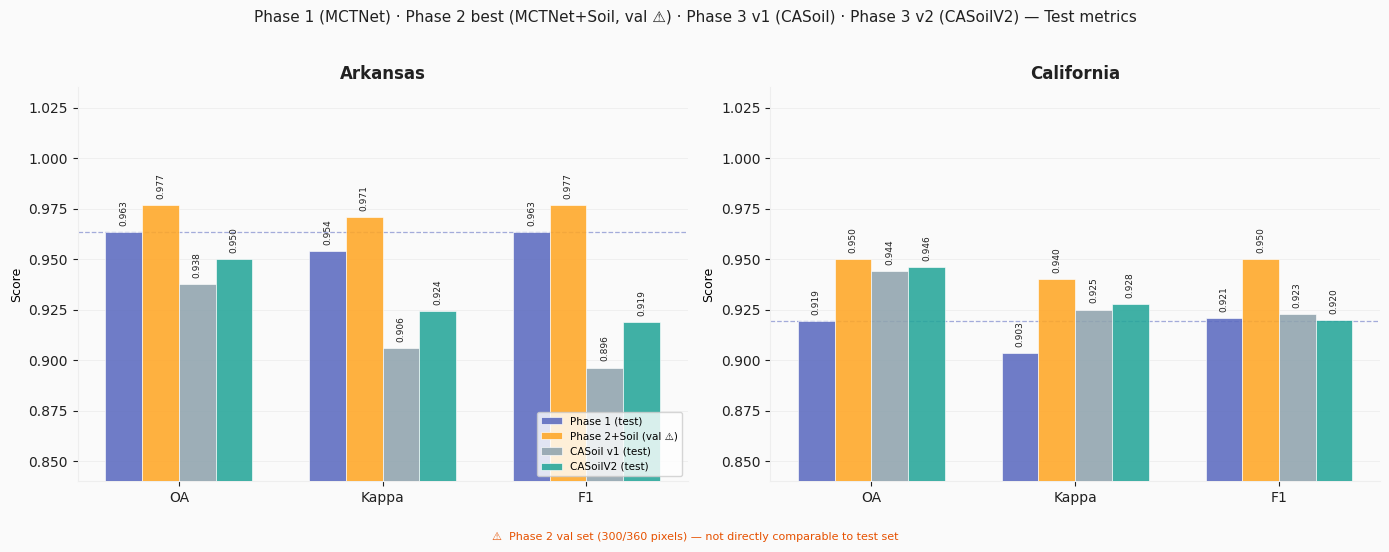

Fig 1 saved → p3v2_comparison_fig1.png


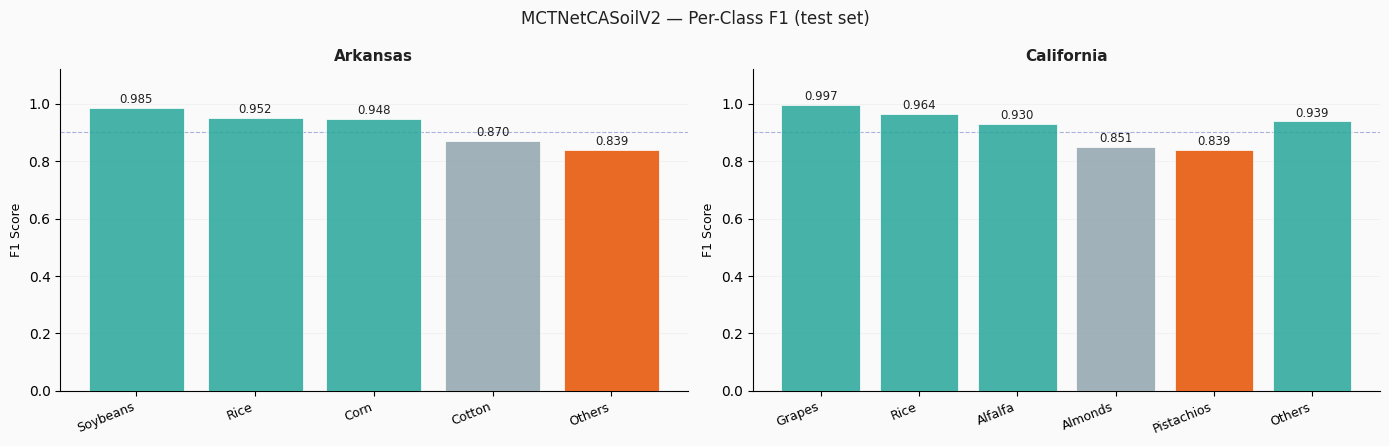

Fig 2 saved → p3v2_comparison_fig2.png


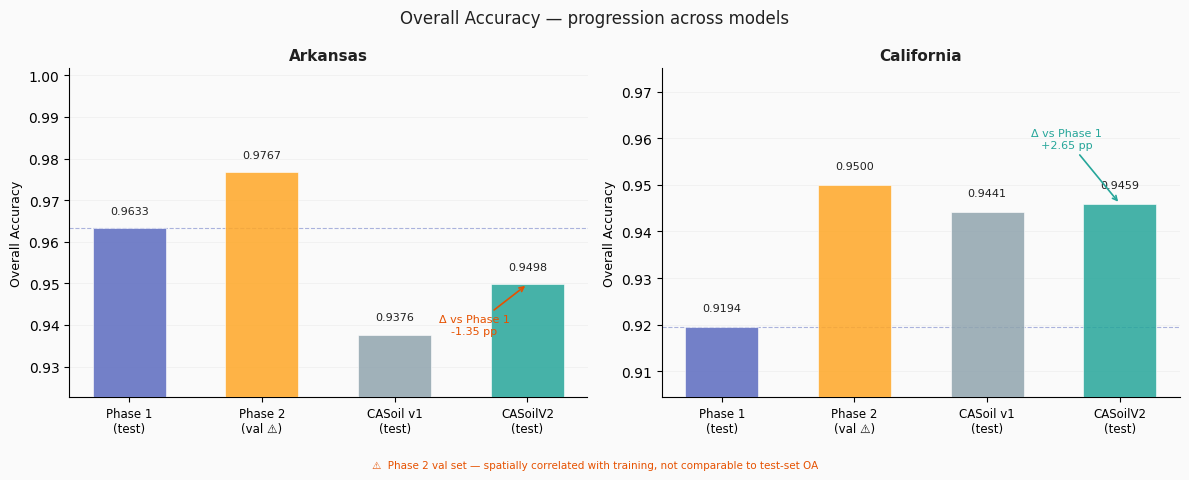

Fig 3 saved → p3v2_comparison_fig3.png

✅ All 3 comparison figures saved to results_new/


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Phase 3 v2 Visual Comparison  (paste into Colab after Cell 7)
#
# Produces 3 figures:
#   Fig 1 – OA / Kappa / F1 grouped bar chart (all 4 models, both regions)
#   Fig 2 – Per-class F1 bar chart  (MCTNetCASoilV2)
#   Fig 3 – OA progression bar + delta annotations
#
# Requires:  matplotlib, numpy (already imported in Cell 1)
# Data:      uses variables defined in Cell 1  (PHASE1, PHASE2_SOIL_VAL,
#            PHASE3_V1)  +  test_results_v2  from Cell 6
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ─── colour palette ───────────────────────────────────────────────────────────
C = {
    "p1"   : "#5C6BC0",   # indigo  – Phase 1  (test)
    "p2"   : "#FFA726",   # amber   – Phase 2  (val, ⚠)
    "v1"   : "#90A4AE",   # steel   – CASoil v1 (test)
    "v2"   : "#26A69A",   # teal    – CASoilV2  (test)
    "bg"   : "#FAFAFA",
    "grid" : "#EEEEEE",
    "text" : "#212121",
    "warn" : "#E65100",
}

METRICS = ["OA", "Kappa", "F1"]
REGIONS = ["arkansas", "california"]
REGION_LABELS = {"arkansas": "Arkansas", "california": "California"}

# ─── data (hard-coded so the cell works stand-alone after a Colab disconnect) ─
DATA = {
    "arkansas": {
        "p1": {"OA": 0.9633, "Kappa": 0.9542, "F1": 0.9632},
        "p2": {"OA": 0.9767, "Kappa": 0.9708, "F1": 0.9767},
        "v1": {"OA": 0.9376, "Kappa": 0.9058, "F1": 0.8963},
        "v2": {"OA": 0.9498, "Kappa": 0.9244, "F1": 0.9188},
    },
    "california": {
        "p1": {"OA": 0.9194, "Kappa": 0.9033, "F1": 0.9209},
        "p2": {"OA": 0.9500, "Kappa": 0.9400, "F1": 0.9501},
        "v1": {"OA": 0.9441, "Kappa": 0.9250, "F1": 0.9227},
        "v2": {"OA": 0.9459, "Kappa": 0.9278, "F1": 0.9199},
    },
}

PER_CLASS = {
    "arkansas": {
        "classes": ["Soybeans", "Rice", "Corn", "Cotton", "Others"],
        "v2":      [0.985,       0.952,  0.948,  0.870,   0.839],
    },
    "california": {
        "classes": ["Grapes", "Rice", "Alfalfa", "Almonds", "Pistachios", "Others"],
        "v2":      [0.997,    0.964,  0.930,     0.851,     0.839,        0.939],
    },
}

# ══════════════════════════════════════════════════════════════════════════════
# FIG 1 – Grouped bar chart: OA / Kappa / F1  for all 4 models
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=C["bg"])
fig1.suptitle(
    "Phase 1 (MCTNet) · Phase 2 best (MCTNet+Soil, val ⚠) · "
    "Phase 3 v1 (CASoil) · Phase 3 v2 (CASoilV2) — Test metrics",
    fontsize=11, color=C["text"], y=1.02
)

MODEL_KEYS   = ["p1", "p2", "v1", "v2"]
MODEL_LABELS = ["Phase 1 (test)", "Phase 2+Soil (val ⚠)", "CASoil v1 (test)", "CASoilV2 (test)"]
COLORS       = [C["p1"], C["p2"], C["v1"], C["v2"]]

BAR_W  = 0.18
OFFSET = np.array([-1.5, -0.5, 0.5, 1.5]) * BAR_W
X      = np.arange(len(METRICS))

for ax, region in zip(axes, REGIONS):
    ax.set_facecolor(C["bg"])
    ax.yaxis.grid(True, color=C["grid"], linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

    for i, (key, label, col) in enumerate(zip(MODEL_KEYS, MODEL_LABELS, COLORS)):
        vals = [DATA[region][key][m] for m in METRICS]
        bars = ax.bar(X + OFFSET[i], vals, BAR_W,
                      label=label, color=col, alpha=0.88,
                      edgecolor="white", linewidth=0.5, zorder=3)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f"{h:.3f}", ha="center", va="bottom",
                    fontsize=6.5, color=C["text"], rotation=90)

    # horizontal reference line at Phase 1 OA
    ax.axhline(DATA[region]["p1"]["OA"], color=C["p1"],
               linestyle="--", linewidth=0.9, alpha=0.55, zorder=2)

    ax.set_xticks(X)
    ax.set_xticklabels(METRICS, fontsize=10)
    ax.set_ylim(0.84, 1.035)
    ax.set_ylabel("Score", fontsize=9)
    ax.set_title(REGION_LABELS[region], fontsize=12, color=C["text"], fontweight="bold")
    ax.tick_params(colors=C["text"])
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color(C["grid"])
    ax.spines["bottom"].set_color(C["grid"])

axes[0].legend(fontsize=7.5, loc="lower right", framealpha=0.8)

# warn annotation
fig1.text(0.5, -0.04,
    "⚠  Phase 2 val set (300/360 pixels) — not directly comparable to test set",
    ha="center", fontsize=8, color=C["warn"])

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/AARN_project/results_new/p3v2_comparison_fig1.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Fig 1 saved → p3v2_comparison_fig1.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 2 – Per-class F1  (MCTNetCASoilV2 on test set)
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4.5), facecolor=C["bg"])
fig2.suptitle("MCTNetCASoilV2 — Per-Class F1 (test set)", fontsize=12, color=C["text"])

for ax, region in zip(axes2, REGIONS):
    ax.set_facecolor(C["bg"])
    classes = PER_CLASS[region]["classes"]
    f1s     = PER_CLASS[region]["v2"]
    x       = np.arange(len(classes))

    bar_cols = [C["v2"] if f >= 0.90 else C["v1"] if f >= 0.85 else C["warn"] for f in f1s]
    bars = ax.bar(x, f1s, color=bar_cols, alpha=0.85,
                  edgecolor="white", linewidth=0.6, zorder=3)
    for bar, f in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, f + 0.006,
                f"{f:.3f}", ha="center", va="bottom", fontsize=8.5, color=C["text"])

    ax.axhline(0.90, color=C["p1"], linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=22, ha="right", fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("F1 Score", fontsize=9)
    ax.set_title(REGION_LABELS[region], fontsize=11, fontweight="bold", color=C["text"])
    ax.yaxis.grid(True, color=C["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/AARN_project/results_new/p3v2_comparison_fig2.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Fig 2 saved → p3v2_comparison_fig2.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 3 – OA progression + delta annotations
# ══════════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4.5), facecolor=C["bg"])
fig3.suptitle("Overall Accuracy — progression across models", fontsize=12, color=C["text"])

MODELS_OA = ["Phase 1\n(test)", "Phase 2\n(val ⚠)", "CASoil v1\n(test)", "CASoilV2\n(test)"]
OA_COLS   = [C["p1"], C["p2"], C["v1"], C["v2"]]

for ax, region in zip(axes3, REGIONS):
    ax.set_facecolor(C["bg"])
    oa_vals = [DATA[region][k]["OA"] for k in MODEL_KEYS]
    x = np.arange(len(MODELS_OA))
    bars = ax.bar(x, oa_vals, color=OA_COLS, alpha=0.85,
                  edgecolor="white", linewidth=0.5, width=0.55, zorder=3)

    for bar, v in zip(bars, oa_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8, color=C["text"])

    # Draw delta arrows v2 vs p1
    d_p1 = DATA[region]["v2"]["OA"] - DATA[region]["p1"]["OA"]
    sign = "+" if d_p1 >= 0 else ""
    fc   = C["v2"] if d_p1 >= 0 else C["warn"]
    ax.annotate(
        f'Δ vs Phase 1\n{sign}{d_p1*100:.2f} pp',
        xy=(3, DATA[region]["v2"]["OA"]),
        xytext=(2.6, DATA[region]["v2"]["OA"] + (0.012 if d_p1 >= 0 else -0.012)),
        fontsize=8, color=fc, ha="center",
        arrowprops=dict(arrowstyle="->", color=fc, lw=1.2),
    )

    ax.axhline(DATA[region]["p1"]["OA"], color=C["p1"],
               linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS_OA, fontsize=8.5)
    lo = min(oa_vals) - 0.015
    hi = max(oa_vals) + 0.025
    ax.set_ylim(lo, hi)
    ax.set_ylabel("Overall Accuracy", fontsize=9)
    ax.set_title(REGION_LABELS[region], fontsize=11, fontweight="bold", color=C["text"])
    ax.yaxis.grid(True, color=C["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)

fig3.text(0.5, -0.04,
    "⚠  Phase 2 val set — spatially correlated with training, not comparable to test-set OA",
    ha="center", fontsize=7.5, color=C["warn"])

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/AARN_project/results_new/p3v2_comparison_fig3.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Fig 3 saved → p3v2_comparison_fig3.png")

print("\n✅ All 3 comparison figures saved to results_new/")